In [1]:
import sys
import os
import pandas as pd

sys.path.append(os.path.abspath(".."))

from src.data_generation import generate_wearable_data

In [2]:
df = generate_wearable_data(days=3)
df.head()

df["timestamp"] = pd.date_range(
    start="2024-01-01",
    periods=len(df),
    freq="min"
)

In [3]:
df.describe()

,minute,hr,hrv,activity,sleep_state,timestamp
count,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320
mean,2159.500000,73.321745,44.857703,0.555829,1.083333,2024-01-02 11:59:30
min,0.000000,38.653463,15.000000,0.000053,1.000000,2024-01-01 00:00:00
25%,1079.750000,60.397159,39.415728,0.252197,1.000000,2024-01-01 17:59:45
50%,2159.500000,71.403355,45.775380,0.495947,1.000000,2024-01-02 11:59:30
75%,3239.250000,82.300473,51.805861,0.753068,1.000000,2024-01-03 05:59:15
max,4319.000000,161.262743,70.756212,3.498561,3.000000,2024-01-03 23:59:00
std,1247.220911,17.277780,9.705620,0.496329,0.343632,NaN


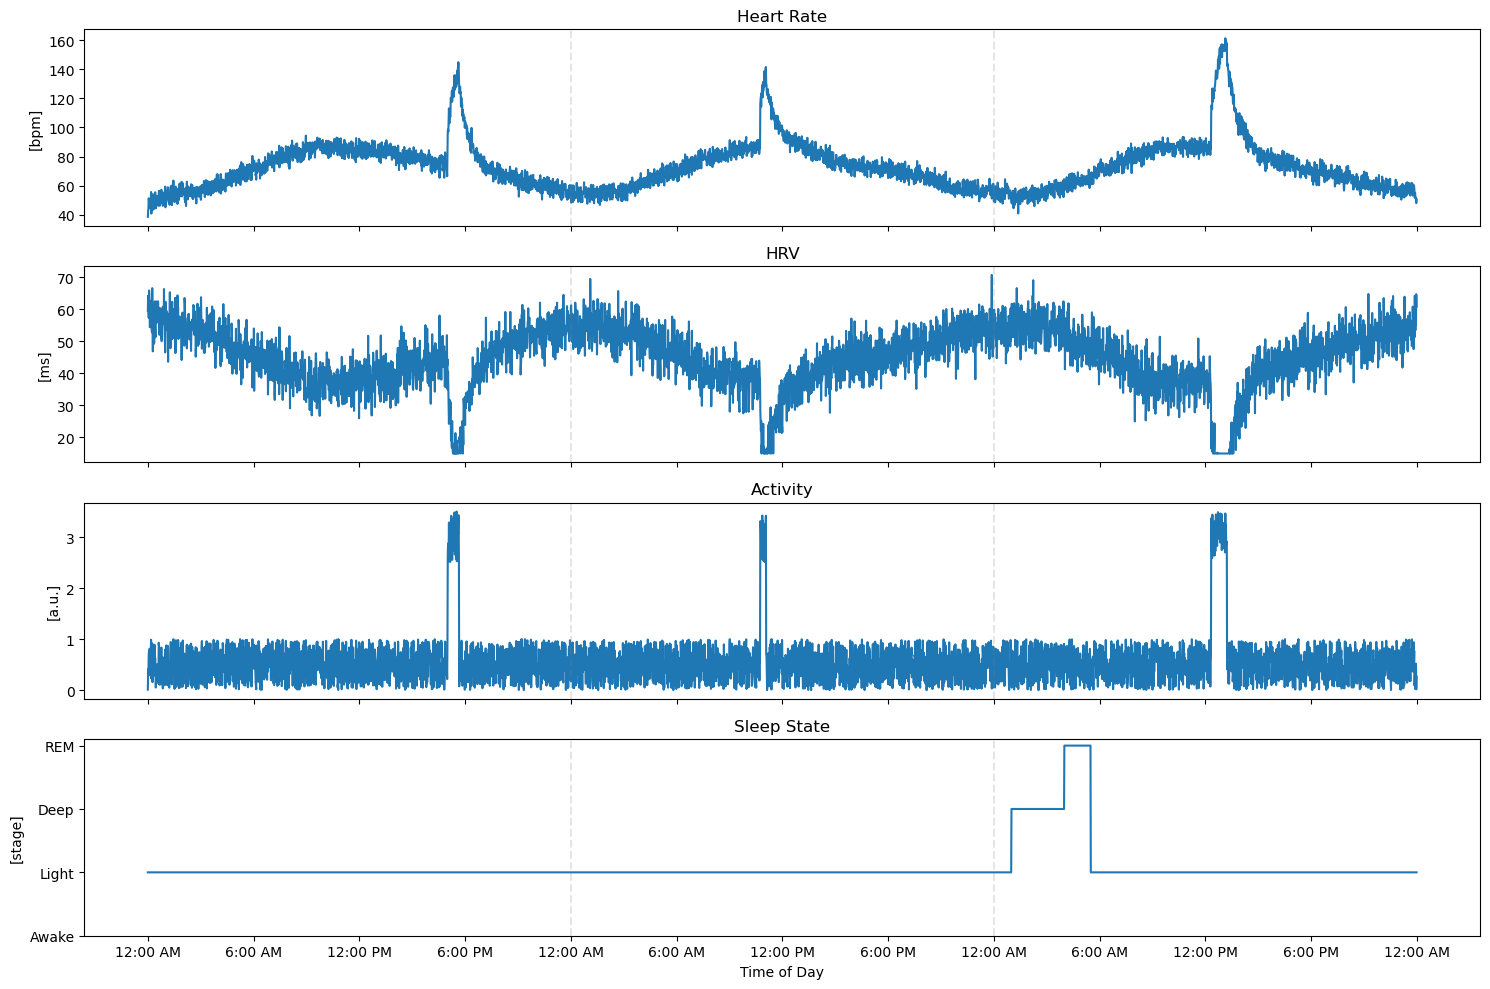

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axs = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

# -------------------------
# Heart Rate
# -------------------------
axs[0].plot(df["timestamp"], df["hr"])
axs[0].set_title("Heart Rate")
axs[0].set_ylabel("[bpm]")

# -------------------------
# HRV
# -------------------------
axs[1].plot(df["timestamp"], df["hrv"])
axs[1].set_title("HRV")
axs[1].set_ylabel("[ms]")

# -------------------------
# Activity
# -------------------------
axs[2].plot(df["timestamp"], df["activity"])
axs[2].set_title("Activity")
axs[2].set_ylabel("[a.u.]")

# -------------------------
# Sleep State
# -------------------------
axs[3].plot(df["timestamp"], df["sleep_state"])
axs[3].set_title("Sleep State")
axs[3].set_ylabel("[stage]")

axs[3].set_yticks([0, 1, 2, 3])
axs[3].set_yticklabels(["Awake", "Light", "Deep", "REM"])

# -------------------------
# X-axis formatting (KEY PART)
# -------------------------

# Show ticks every 6 hours
axs[-1].xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))

# Format as AM/PM only
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%#I:%M %p'))

axs[-1].set_xlabel("Time of Day")

# -------------------------
# Add vertical lines for day boundaries
# -------------------------
minutes_per_day = 1440

for day in range(1, int(len(df) / minutes_per_day)):
    for ax in axs:
        ax.axvline(df["timestamp"].iloc[day * minutes_per_day],
                   linestyle='--', alpha=0.2, color='gray')

plt.tight_layout()
plt.show()

In [5]:
df[["hr", "hrv", "activity"]].corr()

,hr,hrv,activity
hr,1.000000,-0.904139,0.560926
hrv,-0.904139,1.000000,-0.461313
activity,0.560926,-0.461313,1.000000
